# PDF OCR 시각화 도구

Docling OCR 결과를 인터랙티브하게 시각화하는 노트북입니다.

## JupyterLab 서버 시작 방법

터미널에서 다음 명령어를 실행하여 JupyterLab 서버를 시작하세요:

```bash
# JupyterLab 서버 시작 (포트 8000)
uv run jupyter lab --ip=0.0.0.0 --port=8000 --no-browser
```

출력되는 URL과 토큰을 사용하여 브라우저에서 접속:
- **로컬**: `http://localhost:8000/?token=<your-token>`
- **원격 서버**: SSH 포트 포워딩 후 접속
  ```bash
  ssh -L 8000:localhost:8000 user@server
  ```

## 사전 준비

1. **FastAPI 서버**가 실행 중이어야 합니다:
   ```bash
   uv run uvicorn api:app --host 0.0.0.0 --port 3000
   ```

2. **AWS 자격증명**이 설정되어 있어야 합니다 (S3 접근):
   ```bash
   aws configure
   ```

## 주요 기능

- 📁 **S3 파일 브라우저**: S3 버킷을 탐색하고 PDF 선택
- 🔍 **OCR 처리**: Docling 기반 OCR 실행
- 📊 **바운딩 박스 시각화**: 그림(초록), 테이블(빨강) 영역 표시
- 📄 **텍스트 마크다운**: 추출된 텍스트 미리보기
- 💾 **결과 다운로드**: S3 결과를 로컬로 다운로드

## 1. 라이브러리 임포트 및 설정

In [2]:
import requests
import json
import time
from pathlib import Path
from IPython.display import display, Image as IPImage, HTML
from src.s3_browser import create_s3_browser
from src.s3_handler import S3Handler

# API 서버 URL
API_BASE_URL = "http://localhost:3000"

# S3 Handler 초기화
s3 = S3Handler()

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 2. API 서버 Health Check

In [4]:
# Health check
try:
    response = requests.get(f"{API_BASE_URL}/health", timeout=5)
    print(f"Status Code: {response.status_code}")
    print(f"Response: {response.json()}")
    
    if response.status_code == 200:
        print("\n✅ API 서버가 정상적으로 실행 중입니다!")
    else:
        print("\n⚠️  API 서버 응답이 비정상입니다.")
except Exception as e:
    print(f"❌ API 서버에 접근할 수 없습니다: {e}")
    print("\n💡 서버를 시작하세요:")
    print("   uv run uvicorn api:app --host 0.0.0.0 --port 3000")

Status Code: 200
Response: {'status': 'healthy', 'service': 'pdf-parser-api'}

✅ API 서버가 정상적으로 실행 중입니다!


## 3. S3 파일 브라우저로 PDF 선택

S3 버킷을 탐색하고 OCR을 실행할 PDF를 선택하세요.

In [5]:
# 초기 S3 경로 설정 (실제 경로로 변경하세요)
INITIAL_S3_PATH = "s3://miraeasset-product-knowledge-graph/zeroin/"
OUTPUT_BASE = "s3://miraeasset-product-knowledge-graph/output_ocr/"

# S3 브라우저 생성
browser = create_s3_browser(initial_path=INITIAL_S3_PATH)

print("\n💡 사용 방법:")
print("  1. 📁 폴더를 클릭하여 하위 폴더로 이동")
print("  2. 📄 PDF 파일을 클릭하여 선택")
print("  3. ↑ Parent 버튼으로 상위 폴더로 이동")
print("  4. 경로를 직접 입력하고 'Go' 버튼 클릭")
print("\n📝 선택한 PDF는 아래 셀에서 OCR 처리할 수 있습니다.")


💡 사용 방법:
  1. 📁 폴더를 클릭하여 하위 폴더로 이동
  2. 📄 PDF 파일을 클릭하여 선택
  3. ↑ Parent 버튼으로 상위 폴더로 이동
  4. 경로를 직접 입력하고 'Go' 버튼 클릭

📝 선택한 PDF는 아래 셀에서 OCR 처리할 수 있습니다.


## 4. OCR 처리 실행

위에서 선택한 PDF에 대해 OCR을 실행하고 바운딩 박스 시각화 이미지를 생성합니다.

In [8]:
# 선택된 PDF 가져오기
selected_pdf = browser.get_selected()

if not selected_pdf:
    print("⚠️  PDF를 먼저 선택해주세요.")
else:
    print(f"📄 선택된 파일: {selected_pdf}")
    print(f"📂 출력 경로: {OUTPUT_BASE}")
    print("\n🔍 OCR 처리 시작...")
    
    # OCR API 요청
    request_data = {
        "inputPath": selected_pdf,
        "outputPath": OUTPUT_BASE,
        "tableMode": "accurate",
        "generateBboxImages": True
    }
    
    start_time = time.time()
    
    try:
        response = requests.post(
            f"{API_BASE_URL}/ocr",
            json=request_data,
            timeout=600  # 10분 타임아웃
        )
        
        elapsed = time.time() - start_time
        
        print(f"⏱️  요청 소요 시간: {elapsed:.2f}초")
        print(f"📊 응답 코드: {response.status_code}")
        
        if response.status_code == 200:
            result = response.json()
            print("\n✅ OCR 처리 완료!")
            print("=" * 80)
            print(f"텍스트 마크다운: {result['textMarkdownUri']}")
            print(f"바운딩 박스 이미지: {len(result.get('bboxImagesUris', []))}개")
            print(f"\n📊 통계:")
            print(f"  - 페이지 수: {result['stats']['pages']}")
            print(f"  - 그림 수: {result['stats']['figures']}")
            print(f"  - 테이블 수: {result['stats']['tables']}")
            print(f"  - Bbox 이미지: {result['stats']['bboxImages']}개")
            print(f"\n⏱️  서버 처리 시간: {result['elapsedSeconds']}초")
            
            # 결과를 전역 변수에 저장 (다음 셀에서 사용)
            ocr_result = result
        else:
            print(f"\n❌ OCR 처리 실패: {response.status_code}")
            print(response.text)
            ocr_result = None
    
    except Exception as e:
        print(f"\n❌ 오류 발생: {e}")
        ocr_result = None

📄 선택된 파일: s3://miraeasset-product-knowledge-graph/zeroin/r3/R3_A0002C0_001.pdf
📂 출력 경로: s3://miraeasset-product-knowledge-graph/output_ocr/

🔍 OCR 처리 시작...
⏱️  요청 소요 시간: 38.56초
📊 응답 코드: 200

✅ OCR 처리 완료!
텍스트 마크다운: s3://miraeasset-product-knowledge-graph/output_ocr/R3_A0002C0_001/R3_A0002C0_001_text.md
바운딩 박스 이미지: 4개

📊 통계:
  - 페이지 수: 4
  - 그림 수: 0
  - 테이블 수: 7
  - Bbox 이미지: 4개

⏱️  서버 처리 시간: 38.53초


## 5. 바운딩 박스 시각화 이미지 표시

S3에서 바운딩 박스 이미지를 다운로드하여 표시합니다.
- **초록색**: 그림(Figure) 영역
- **빨간색**: 테이블(Table) 영역

🖼️  바운딩 박스 이미지 표시 (4개)


📄 페이지 1


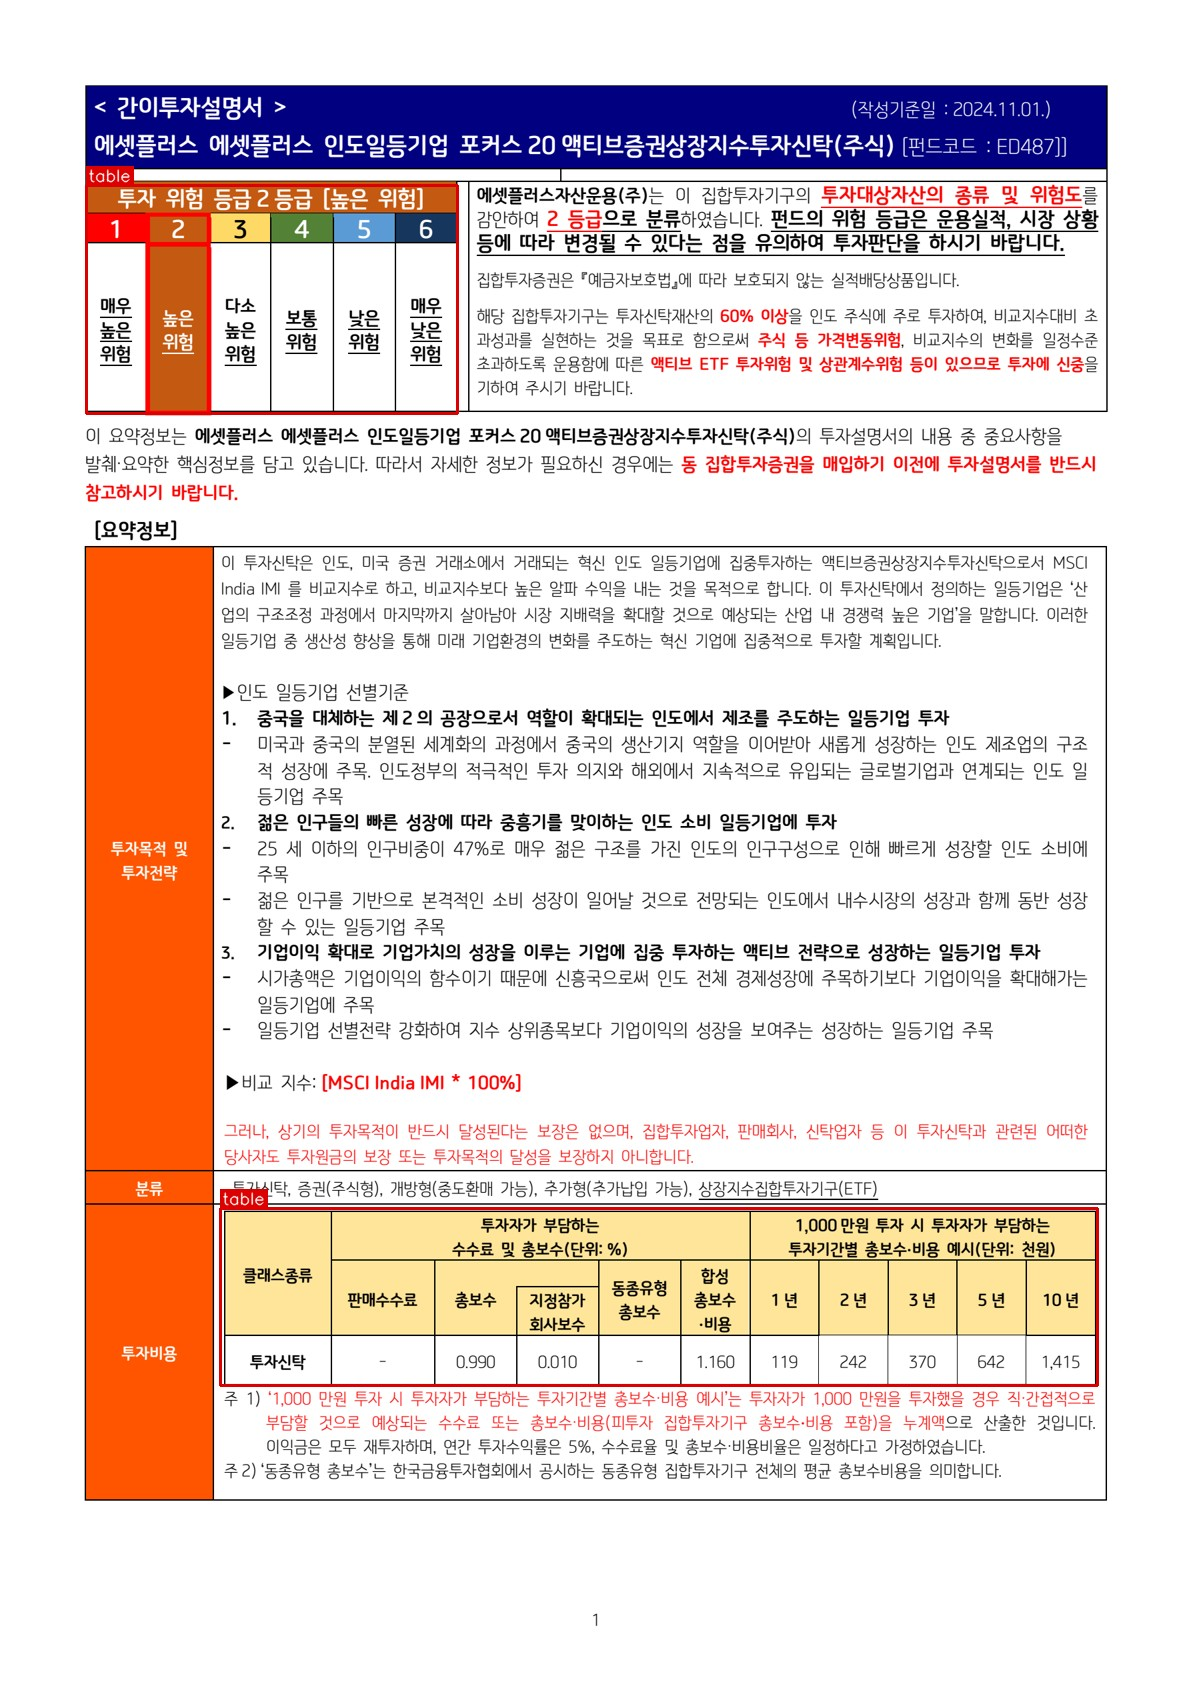


📄 페이지 2


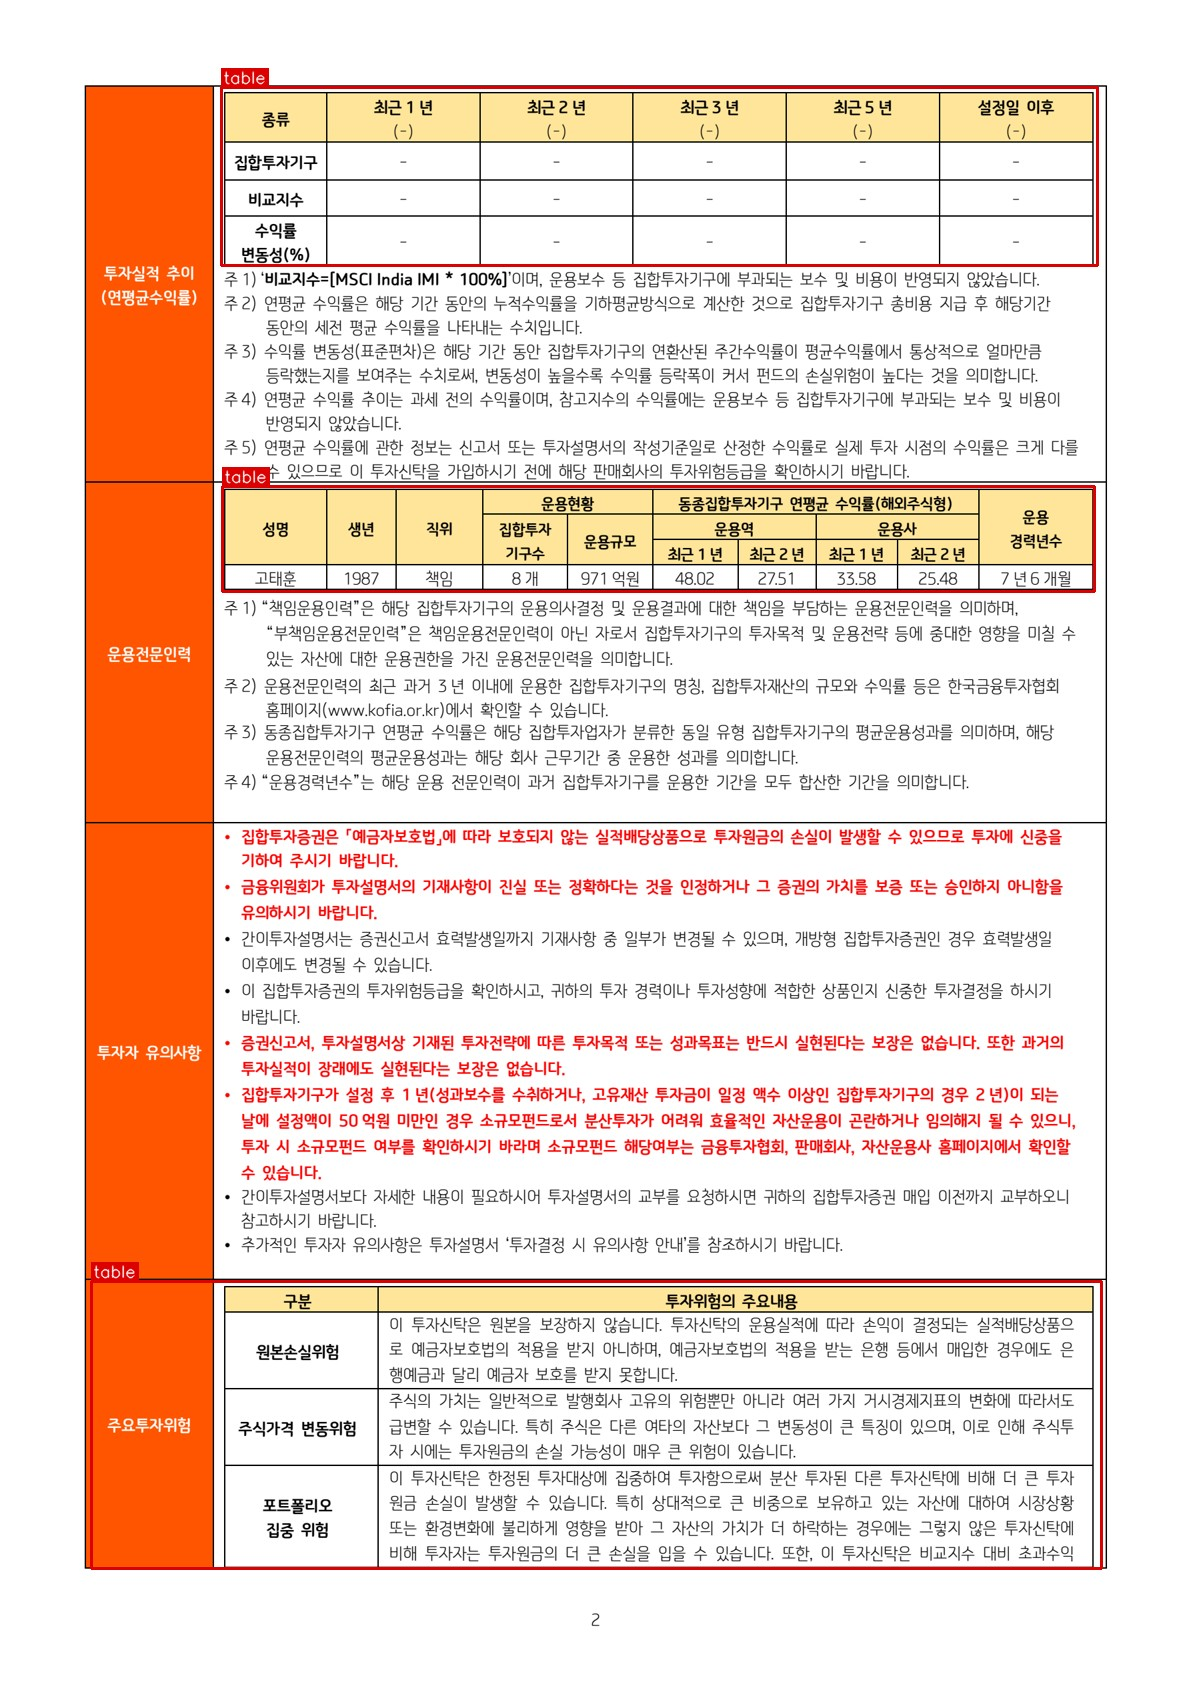


📄 페이지 3


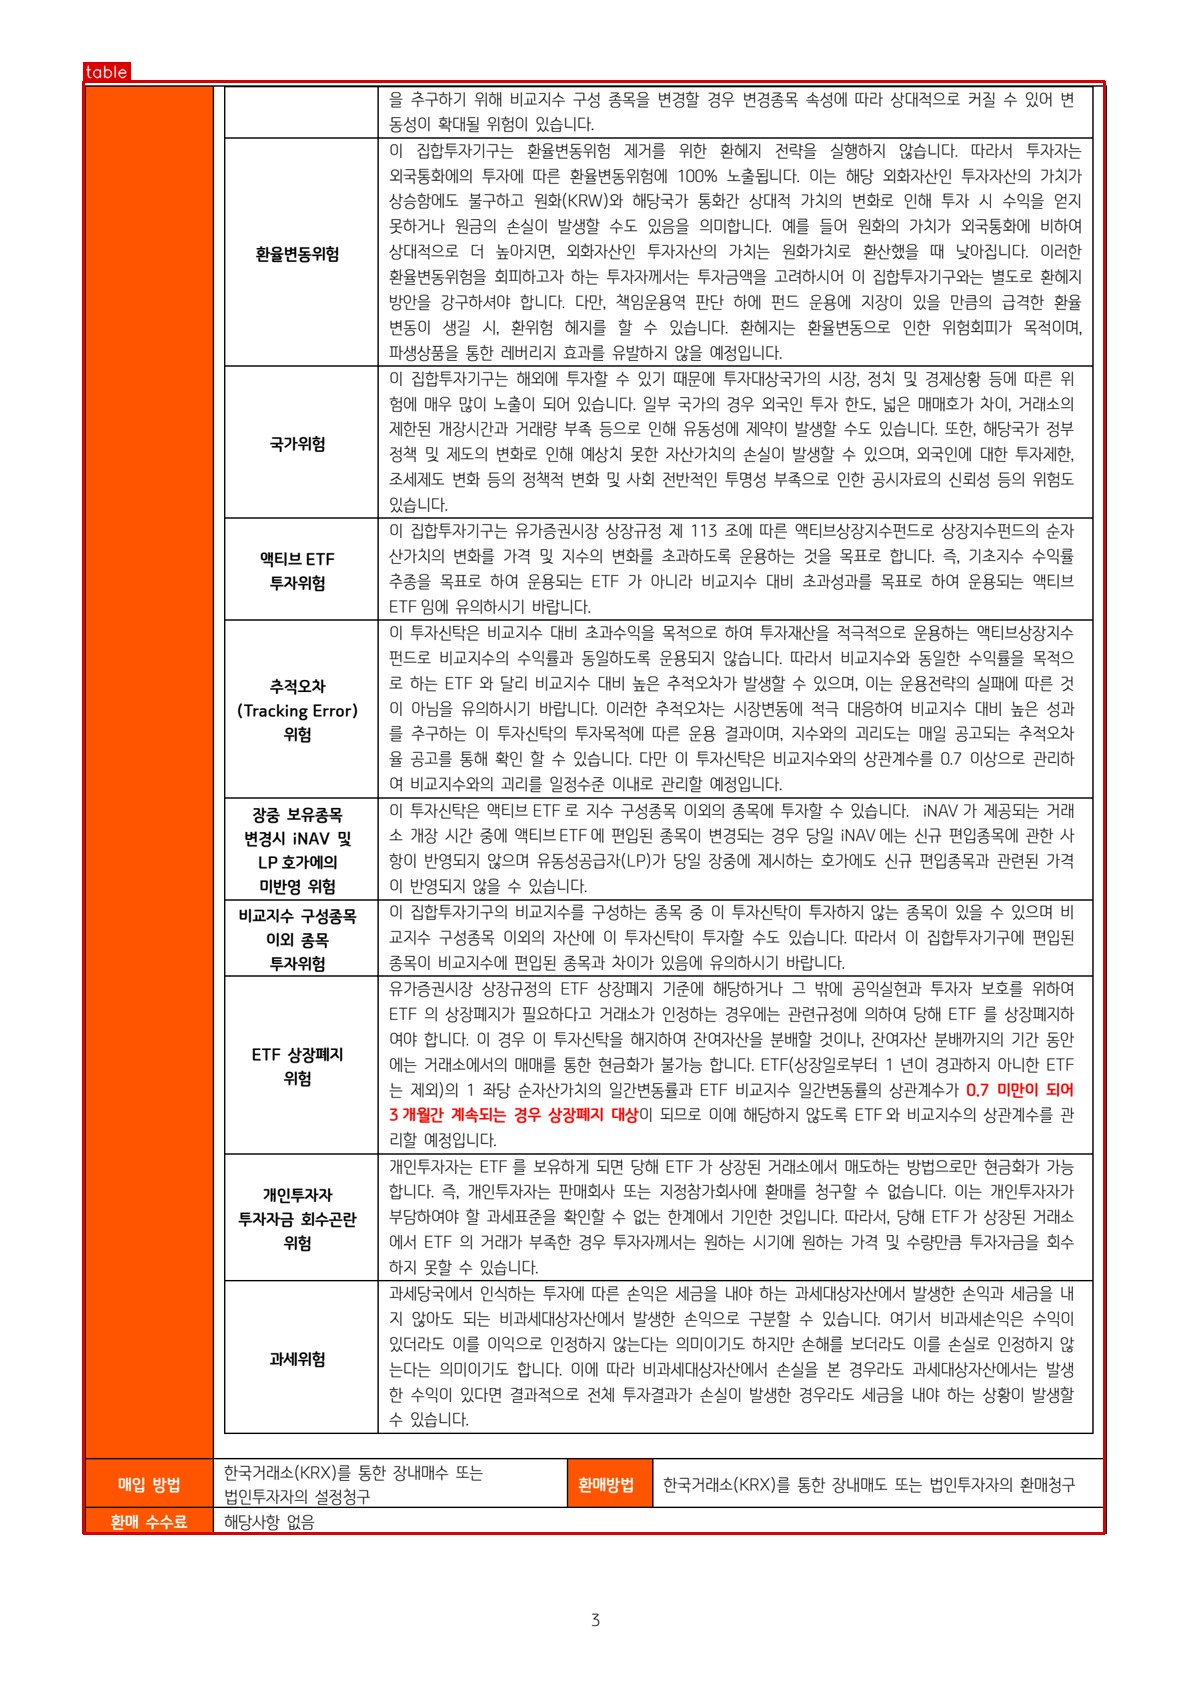


📄 페이지 4


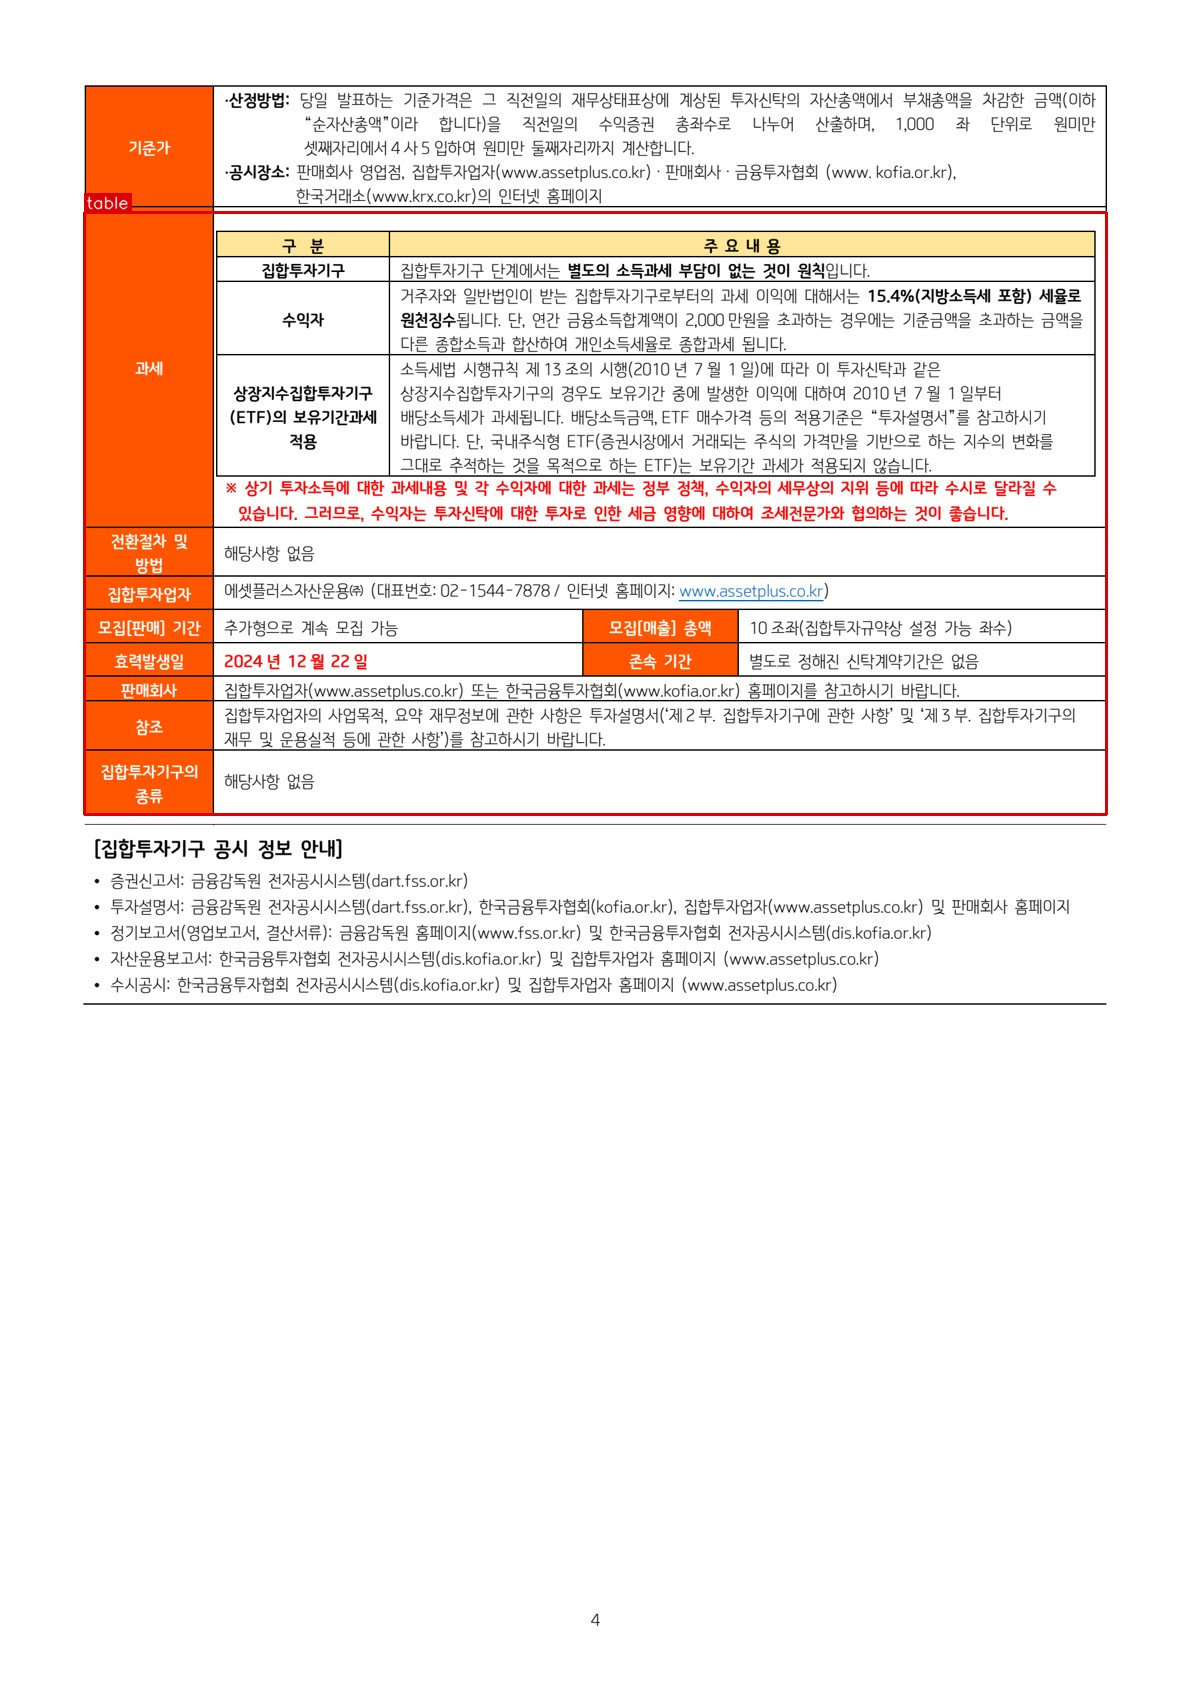


✅ 4개 이미지 표시 완료


In [9]:
if 'ocr_result' not in locals() or not ocr_result:
    print("⚠️  먼저 OCR 처리를 실행해주세요.")
elif not ocr_result.get('bboxImagesUris'):
    print("⚠️  바운딩 박스 이미지가 생성되지 않았습니다.")
else:
    bbox_uris = ocr_result['bboxImagesUris']
    print(f"🖼️  바운딩 박스 이미지 표시 ({len(bbox_uris)}개)\n")
    
    # 임시 디렉토리에 다운로드
    temp_bbox_dir = Path("./temp_bbox")
    temp_bbox_dir.mkdir(exist_ok=True)
    
    for i, uri in enumerate(sorted(bbox_uris), 1):
        # 페이지 번호 추출
        page_no = i
        
        try:
            # S3에서 다운로드
            bucket, key = s3.parse_s3_uri(uri)
            local_path = temp_bbox_dir / Path(key).name
            
            response = s3._client.get_object(Bucket=bucket, Key=key)
            img_bytes = response['Body'].read()
            local_path.write_bytes(img_bytes)
            
            # 이미지 표시
            print(f"\n{'='*80}")
            print(f"📄 페이지 {page_no}")
            print(f"{'='*80}")
            display(IPImage(filename=str(local_path), width=800))
            
        except Exception as e:
            print(f"❌ 페이지 {page_no} 이미지 로드 실패: {e}")
    
    print(f"\n✅ {len(bbox_uris)}개 이미지 표시 완료")

## 10. 요약

이 노트북에서 다룬 내용:

1. ✅ API Health Check
2. ✅ S3 파일 브라우저로 PDF 선택
3. ✅ OCR API 호출 및 처리
4. ✅ 바운딩 박스 시각화 이미지 표시
5. ✅ 텍스트 마크다운 미리보기
6. ✅ 전체 결과 다운로드
7. ✅ 통계 요약
8. ✅ 유틸리티 함수

### API 문서

- Swagger UI: http://localhost:3000/docs
- OCR 엔드포인트: POST http://localhost:3000/ocr

### 다음 단계

- **전체 파이프라인**: `api_test.ipynb`에서 LLM 요약 포함 전체 처리
- **로컬 처리**: `pdf_parser_docling.ipynb`에서 로컬 PDF 직접 처리
- **API 서버**: `api.py`에서 `/process` 엔드포인트로 전체 파이프라인 실행